The objective of this mini-project is to define and train a Conditional VAE
(CVAE)

D'après IBM : 

L’un des inconvénients des VAE « vanilla » classiques est que l’utilisateur n’a aucun contrôle sur les sorties spécifiques générées par l’auto-encodeur. Par exemple, un VAE classique entraîné à partir du jeu de données MNIST mentionné précédemment générera de nouveaux échantillons de chiffres manuscrits compris entre 0 et 9, mais il ne peut pas être contraint de ne produire que des 4 et des 7.

Comme leur nom l'indique, les VAE conditionnelles (CVAE) permettent d'obtenir des sorties conditionnées par des entrées spécifiques, plutôt que de générer uniquement des variations de données d'entraînement au hasard. Pour ce faire, des éléments d'apprentissage supervisé (ou semi-supervisé) sont incorporés aux objectifs de formation traditionnellement non supervisés des auto-encodeurs conventionnels.

En entraînant le modèle sur des exemples étiquetés de variables spécifiques, ces variables peuvent être utilisées pour conditionner la sortie du décodeur. Par exemple, un CVAE peut d'abord être entraîné sur un grand jeu de données d'images faciales, puis en utilisant l'apprentissage supervisé pour apprendre un codage latent pour les « barbes » afin qu'il puisse produire de nouvelles images de visages barbus.


D'après https://medium.com/@mathparracho/variational-autoencoders-vaes-cvaes-%CE%B2-vaes-generative-intuition-practice-4b7b4011f55b

What is a Conditional Variational Autoencoder (CVAE)?

The CVAE (Conditional Variational Autoencoder) is a modification of the traditional VAE that introduces conditional outputs based on the input data.

Here we introduce a simple trick to make the network conditional to the input:
Press enter or click to view image in full size
Label Concatenation in the Channel Dimension

The idea is simply to concatenate the information we want to conditionalize in the channel dimension:

class ConditionalEncoder(nn.Module):
    def __init__(self, input_channels, hidden_dim, z_dim, num_classes):
        super(Encoder, self).__init__()
        self.num_classes = num_classes
        self.conv1 = nn.Conv2d(input_channels + num_classes, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.fc_mu = nn.Linear(128 * 4 * 4, z_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, z_dim)

    def forward(self, x, labels):

        # one-hot encode labels and expand dimensions shape [batch_size, num_classes, spatialY, spatialX],
        y = one_hot_encode(labels, self.num_classes).unsqueeze(2).unsqueeze(3) # [64, 10, 1, 1]
        y = y.expand(-1, -1, x.size(2), x.size(3)) #[64, 10, 28, 28] make a "layer of conditional information"
        # concatenate along the channel dimension
        x = torch.cat([x, y], dim=1)


        h = F.relu(self.conv1(x))
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

Bonus: We can find a similar approach to deal with spatial coordinates here in this paper with CoorConvs: Paper

So, for instance, if I want to generate only new “0” samples:
Press enter or click to view image in full size

Or, if I want to generate only new “1” samples:
Press enter or click to view image in full size

Or, only new “2” samples:
Press enter or click to view image in full size




In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


https://medium.com/@sofeikov/implementing-conditional-variational-auto-encoders-cvae-from-scratch-29fcbb8cb08f

https://github.com/timbmg/VAE-CVAE-MNIST/blob/master/train.py

https://github.com/chendaichao/VAE-pytorch/blob/master/Models/VAE/Demo.ipynb

https://pyro.ai/examples/cvae.html

https://deepwiki.com/gozsoy/conditional-vae/3.2-conditional-vae-architecture

https://github.com/unnir/cVAE

In [8]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='data_cvae', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='data_cvae', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100.0%
100.0%
100.0%
100.0%


In [63]:
for batch_idx, (data, label) in enumerate(train_loader): # label c'est le y
        data = data.to(device)
        #print(data)
        label = label.to(device)
        print(label)

tensor([1, 3, 7, 5, 2, 3, 8, 4, 0, 0, 4, 0, 1, 0, 7, 2, 5, 8, 3, 6, 9, 0, 8, 4,
        8, 4, 8, 6, 7, 1, 0, 9, 7, 0, 9, 9, 5, 7, 7, 1, 6, 6, 1, 1, 2, 1, 8, 0,
        2, 1, 4, 6, 6, 1, 6, 7, 9, 1, 0, 5, 8, 9, 8, 1, 6, 3, 0, 5, 0, 9, 2, 4,
        1, 8, 1, 7, 8, 5, 3, 8, 8, 5, 0, 0, 7, 5, 6, 9, 4, 7, 7, 2, 5, 4, 4, 1,
        3, 1, 7, 4, 4, 7, 5, 2, 5, 2, 1, 4, 6, 9, 4, 4, 7, 9, 8, 3, 7, 2, 6, 3,
        8, 4, 9, 3, 4, 7, 2, 0], device='cuda:0')
tensor([8, 0, 6, 6, 8, 3, 2, 1, 3, 6, 0, 9, 0, 6, 9, 5, 9, 4, 0, 8, 8, 4, 1, 8,
        1, 5, 2, 9, 0, 8, 1, 9, 3, 3, 7, 8, 1, 3, 6, 7, 5, 0, 0, 6, 5, 7, 5, 7,
        5, 1, 2, 6, 0, 8, 6, 7, 9, 5, 1, 0, 4, 4, 3, 5, 1, 7, 4, 9, 4, 1, 6, 1,
        4, 0, 9, 7, 8, 3, 7, 8, 1, 5, 0, 8, 0, 6, 1, 4, 2, 1, 2, 3, 1, 2, 1, 9,
        9, 8, 7, 9, 1, 8, 1, 1, 1, 6, 6, 4, 7, 8, 6, 8, 7, 7, 6, 9, 6, 2, 1, 7,
        8, 9, 7, 7, 8, 4, 9, 6], device='cuda:0')
tensor([0, 2, 5, 7, 9, 2, 2, 8, 7, 3, 5, 9, 7, 2, 9, 7, 9, 1, 2, 2, 9, 9, 4, 7,
        0, 6, 0, 7, 

In [93]:
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=10):
        super(ConditionalVAE, self).__init__()
        self.latent_dim = latent_dim
        self.label_embedding = nn.Embedding(10, 16) # sert à créer un vecteur des labels
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Output: (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Fully connected layers for mean and log variance
        self.fc_mu = nn.Linear(128 * 4 * 4 + 16, latent_dim) 
        self.fc_logvar = nn.Linear(128 * 4 * 4 + 16, latent_dim) 
        self.fc_decode = nn.Linear(latent_dim + 16, 128 * 4 * 4) 
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # Output: (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: (1, 28, 28)
            nn.Sigmoid()
        )
    
    def encode(self, x, y):
        x = self.encoder(x)
        x = x.view(-1, 128 * 4 * 4) # Flatten the output of the convolutional layers
        y = self.label_embedding(y)
        mu = self.fc_mu(torch.cat((x,y),dim=1))
        logvar = self.fc_logvar(torch.cat((x,y),dim=1))
        return mu, logvar
    

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, y):
        y = self.label_embedding(y)
        x = self.fc_decode(torch.cat((z,y),dim=1))
        x = x.view(-1, 128, 4, 4)  # Reshape to (128, 4, 4) for the decoder
        x = self.decoder(x)
        return x

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.sample(mu, logvar)
        return self.decode(z, y), mu, logvar 
    


In [78]:
# TODO: Implement the loss function
def loss_function(recon_x, x, mu, logvar, beta=1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD, BCE, KLD

In [81]:
# Hyperparameters
batch_size = 128
latent_dim = 2
learning_rate = 1e-3
epochs = 30
beta = 1

# Initialize the CVAE model and the Adam optimizer
cvae = ConditionalVAE(latent_dim=latent_dim)
cvae.to(device)
optimizer = optim.Adam(cvae.parameters(), lr=learning_rate)

# Train the model for the given number of epochs
# At the end of each epoch, print the training loss

losses = []  # liste pour stocker les pertes
BCE = []
KLD = []
val_losses = [] # liste pour stocker la validation loss

for epoch in range(1, epochs + 1):
    cvae.train()
    running_loss = 0.0
    running_bce = 0.0
    running_kld = 0.0
    for batch_idx, (data, label) in enumerate(train_loader): # label c'est le y
        data = data.to(device)
        label = label.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = cvae(data, label)
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_bce += bce.item()
        running_kld += kld.item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_bce = running_bce / len(train_loader.dataset)
    epoch_kld = running_kld / len(train_loader.dataset)

    losses.append(epoch_loss)  # on sauvegarde la perte
    BCE.append(epoch_bce)
    KLD.append(epoch_kld)


    # --- Validation ---
    cvae.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for batch_idx, (data, label) in enumerate(test_loader):
            data = data.to(device)
            label = label.to(device)
            recon_batch, mu, logvar = cvae(data, label)
            val_loss, _, _ = loss_function(recon_batch, data, mu, logvar)
            val_running_loss += val_loss.item()
    
    epoch_val_loss = val_running_loss / len(test_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f'Epoch {epoch}, Training loss: {epoch_loss:.4f}')



dimension z : torch.Size([128, 2])
dimension x : torch.Size([128, 2048])
dimension x : torch.Size([128, 128, 4, 4])
dimension x : torch.Size([128, 1, 28, 28])
dimension z : torch.Size([128, 2])
dimension x : torch.Size([128, 2048])
dimension x : torch.Size([128, 128, 4, 4])
dimension x : torch.Size([128, 1, 28, 28])
dimension z : torch.Size([128, 2])
dimension x : torch.Size([128, 2048])
dimension x : torch.Size([128, 128, 4, 4])
dimension x : torch.Size([128, 1, 28, 28])
dimension z : torch.Size([128, 2])
dimension x : torch.Size([128, 2048])
dimension x : torch.Size([128, 128, 4, 4])
dimension x : torch.Size([128, 1, 28, 28])
dimension z : torch.Size([128, 2])
dimension x : torch.Size([128, 2048])
dimension x : torch.Size([128, 128, 4, 4])
dimension x : torch.Size([128, 1, 28, 28])
dimension z : torch.Size([128, 2])
dimension x : torch.Size([128, 2048])
dimension x : torch.Size([128, 128, 4, 4])
dimension x : torch.Size([128, 1, 28, 28])
dimension z : torch.Size([128, 2])
dimension x

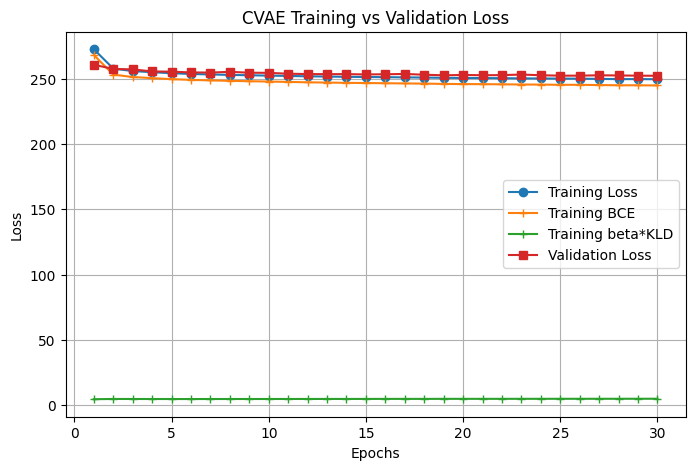

In [86]:

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), losses, marker='o', label='Training Loss')
plt.plot(range(1, epochs+1), BCE, marker='+', label='Training BCE')
plt.plot(range(1, epochs+1), beta * KLD, marker='+', label='Training beta*KLD')
plt.plot(range(1, epochs+1), val_losses, marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CVAE Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [49]:
import matplotlib.pyplot as plt

def image_comparison(original_images, reconstructions, n_images=6):
    """Plots the original images and its reconstructions for comparison

    Args:
        original_image (torch.Tensor): The original images
        reconstructions (torch.Tensor): Reconstruction of the original images
    """
    fig, ax = plt.subplots(2, n_images, figsize=(20, 7))
    
    for i in range(n_images):
        # Plot original images
        ax[0, i].imshow(original_images[i], cmap='gray')
        ax[0, i].axis('off')
        ax[0, 0].set_title('Original')

        # Reconstructed images
        ax[1, i].imshow(reconstructions[i], cmap='gray')
        ax[1, i].axis('off')
        ax[1, 0].set_title('Recomstruction')
    
    plt.tight_layout()
    plt.show()

dimension z : torch.Size([128, 2])
dimension x : torch.Size([128, 2048])
dimension x : torch.Size([128, 128, 4, 4])
dimension x : torch.Size([128, 1, 28, 28])


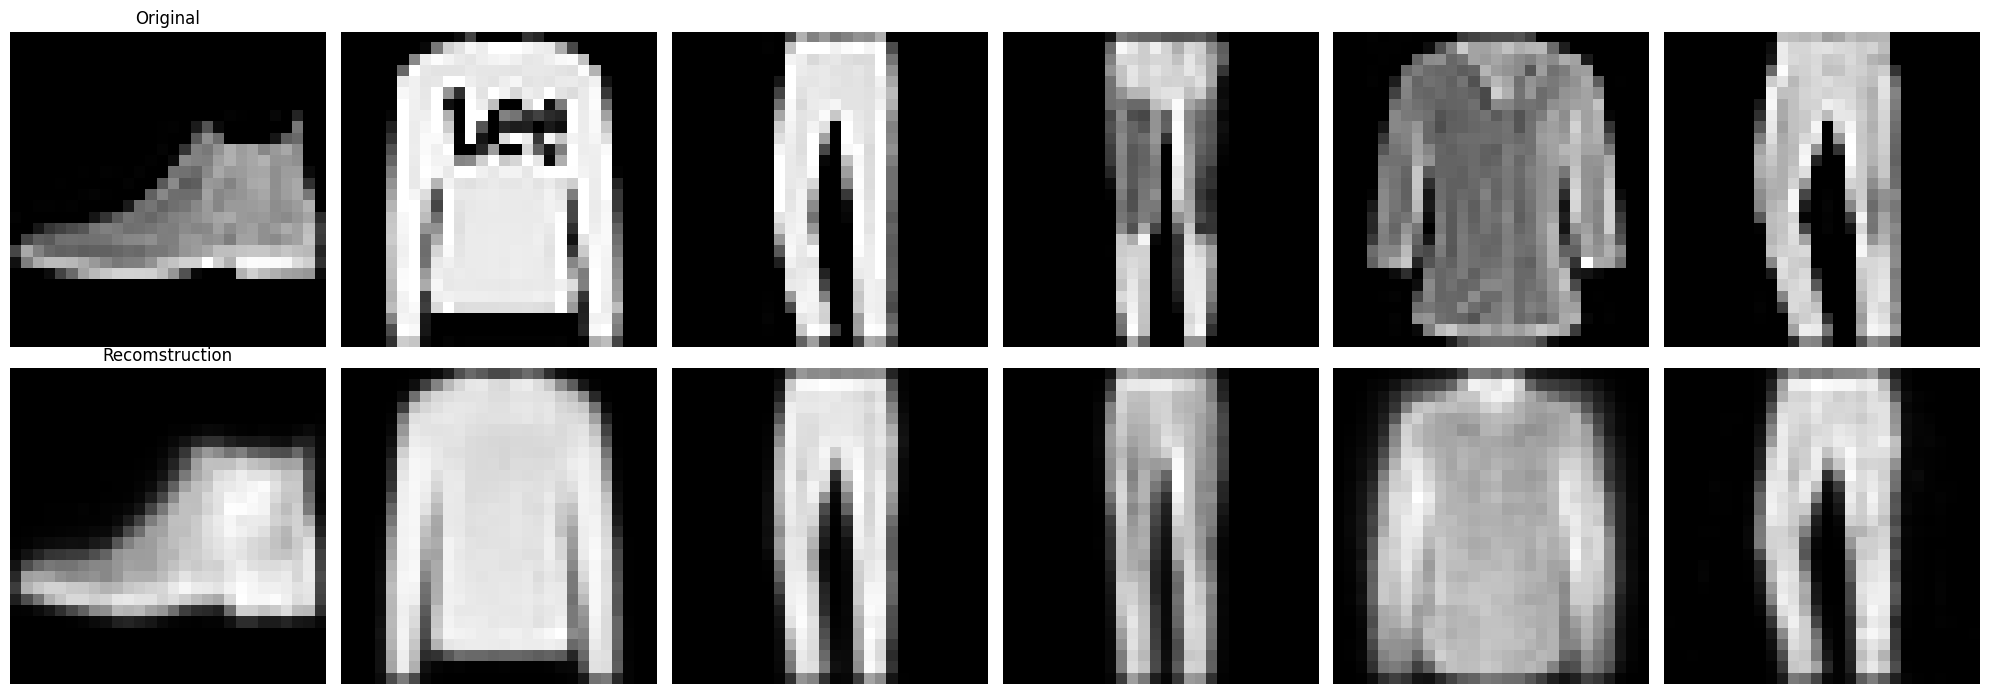

In [ ]:
# Select a batch of images from the test dataset
random_images = next(iter(test_loader))

# Get the reconstructions of the selected images
recons, _, _ = cvae(random_images[0].to(device),random_images[1].to(device))

# Reshape the images for plotting
random_images = random_images[0].cpu().numpy().squeeze()
recons = recons.detach().cpu().numpy().squeeze()

# Plot the original images and their reconstructions
image_comparison(random_images, recons)

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


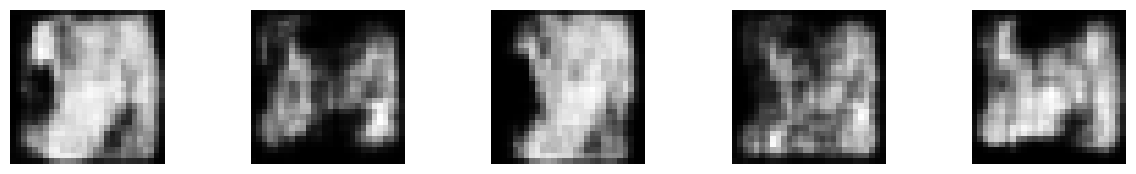

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


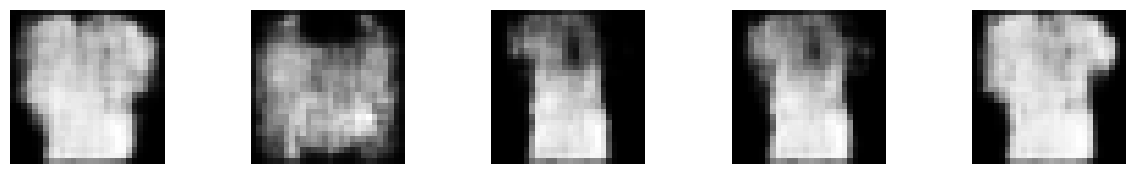

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


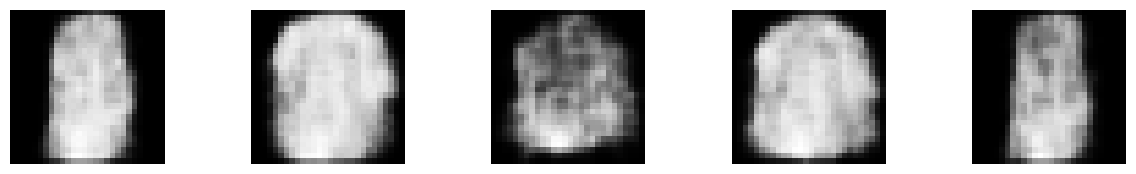

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


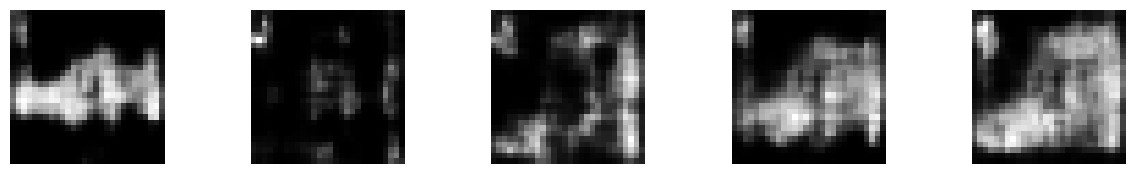

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


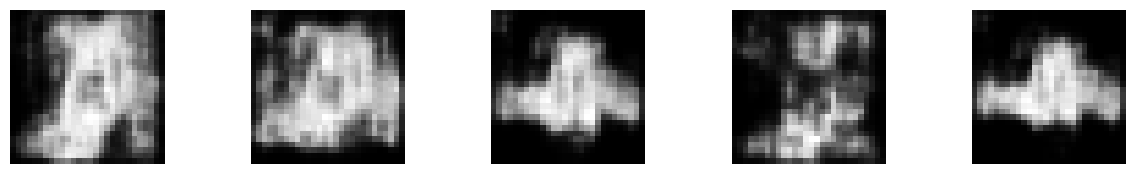

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


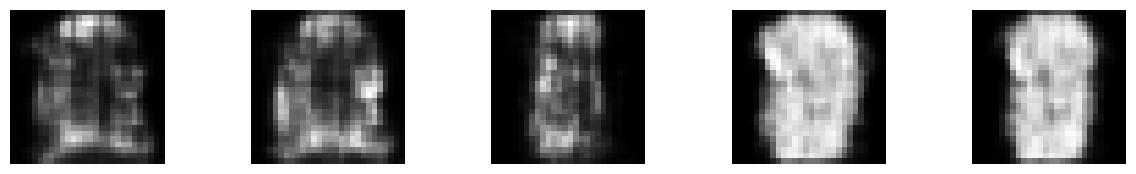

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


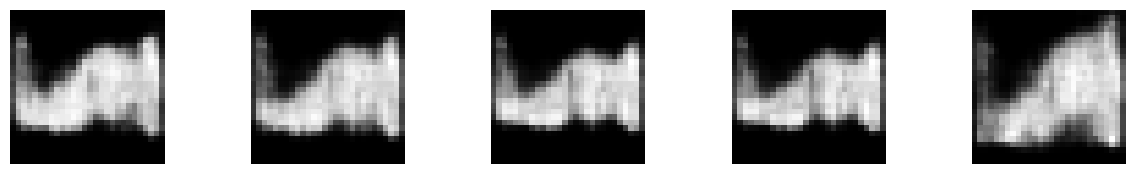

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


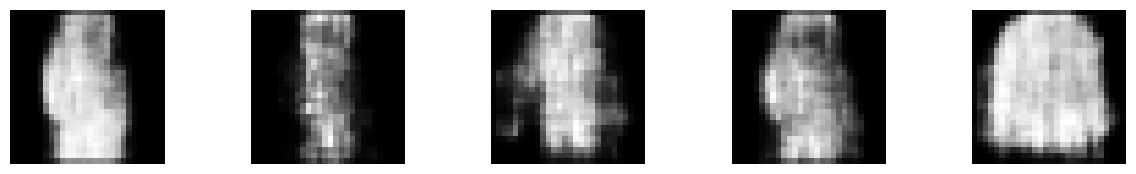

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


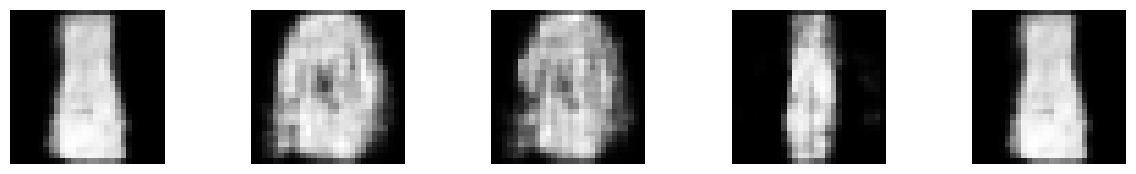

dimension z : torch.Size([5, 2])
dimension x : torch.Size([5, 2048])
dimension x : torch.Size([5, 128, 4, 4])
dimension x : torch.Size([5, 1, 28, 28])


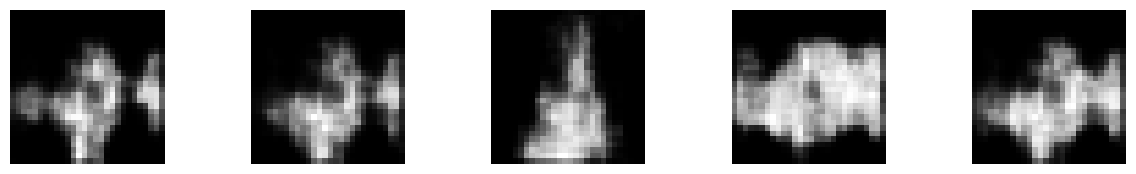

In [72]:
def generate_sample(num_samples=5):
    cvae.eval()
    with torch.no_grad():
        for i in range(10):
            random_samples = torch.randn(num_samples, latent_dim).to(device)
            label_embedding = nn.Embedding(10, 16)
            label = label_embedding(torch.tensor([i,i,i,i,i])).to(device)
            samples = cvae.decode(random_samples, label)
            samples = samples.cpu().view(num_samples, 1, 28, 28) # Reshape the samples

            fig, ax = plt.subplots(1, num_samples, figsize=(15, 2))
            for i in range(num_samples):
                ax[i].imshow(samples[i].squeeze(0), cmap='gray')
                ax[i].axis('off')
            plt.show()

generate_sample()


Training VAE with KL Weight = 1
Epoch 1: Average Loss: 274.9420, BCE: 270.4447, KLD: 4.4974
Epoch 2: Average Loss: 256.9487, BCE: 252.3006, KLD: 4.6481
Epoch 3: Average Loss: 254.9213, BCE: 250.3067, KLD: 4.6146
Epoch 4: Average Loss: 254.0145, BCE: 249.4125, KLD: 4.6020
Epoch 5: Average Loss: 253.3984, BCE: 248.8098, KLD: 4.5886
Epoch 6: Average Loss: 252.9392, BCE: 248.3492, KLD: 4.5900
Epoch 7: Average Loss: 252.5390, BCE: 247.9658, KLD: 4.5732
Epoch 8: Average Loss: 252.2187, BCE: 247.6226, KLD: 4.5961
Epoch 9: Average Loss: 251.9703, BCE: 247.3789, KLD: 4.5915
Epoch 10: Average Loss: 251.7259, BCE: 247.1184, KLD: 4.6076


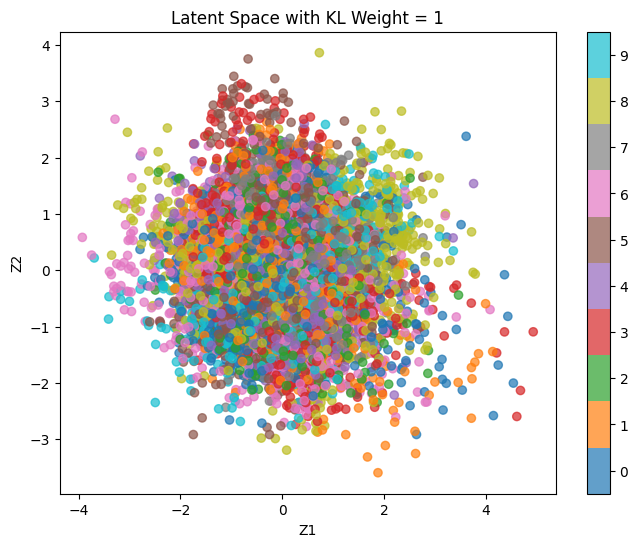


Training VAE with KL Weight = 10
Epoch 1: Average Loss: 296.2957, BCE: 283.6830, KLD: 1.2613
Epoch 2: Average Loss: 281.8759, BCE: 265.9039, KLD: 1.5972
Epoch 3: Average Loss: 279.9189, BCE: 262.9580, KLD: 1.6961
Epoch 4: Average Loss: 279.0479, BCE: 261.7802, KLD: 1.7268
Epoch 5: Average Loss: 278.6958, BCE: 261.1809, KLD: 1.7515
Epoch 6: Average Loss: 278.3743, BCE: 260.6639, KLD: 1.7710
Epoch 7: Average Loss: 278.0064, BCE: 260.2814, KLD: 1.7725
Epoch 8: Average Loss: 277.8381, BCE: 259.9398, KLD: 1.7898
Epoch 9: Average Loss: 277.6011, BCE: 259.7162, KLD: 1.7885
Epoch 10: Average Loss: 277.6199, BCE: 259.5693, KLD: 1.8051


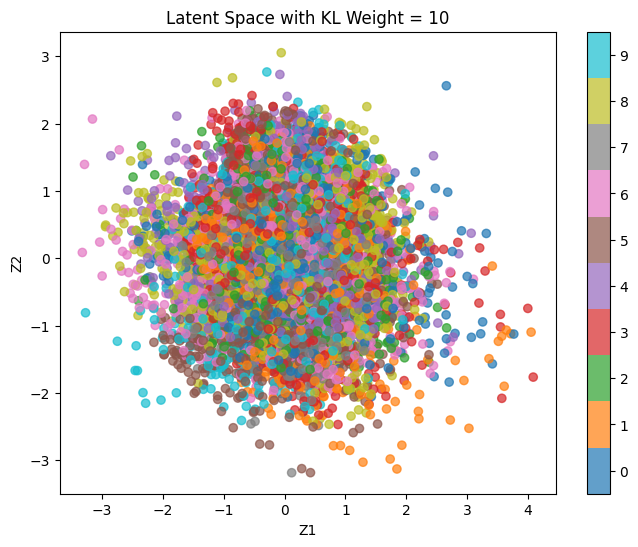


Training VAE with KL Weight = 100
Epoch 1: Average Loss: 318.5932, BCE: 316.3300, KLD: 0.0226
Epoch 2: Average Loss: 308.1486, BCE: 308.0855, KLD: 0.0006
Epoch 3: Average Loss: 307.8657, BCE: 307.8372, KLD: 0.0003
Epoch 4: Average Loss: 307.7407, BCE: 307.7216, KLD: 0.0002
Epoch 5: Average Loss: 307.6596, BCE: 307.6455, KLD: 0.0001
Epoch 6: Average Loss: 307.6124, BCE: 307.6032, KLD: 0.0001
Epoch 7: Average Loss: 307.5717, BCE: 307.5624, KLD: 0.0001
Epoch 8: Average Loss: 307.5622, BCE: 307.5545, KLD: 0.0001
Epoch 9: Average Loss: 307.5635, BCE: 307.5596, KLD: 0.0000
Epoch 10: Average Loss: 307.5179, BCE: 307.5146, KLD: 0.0000


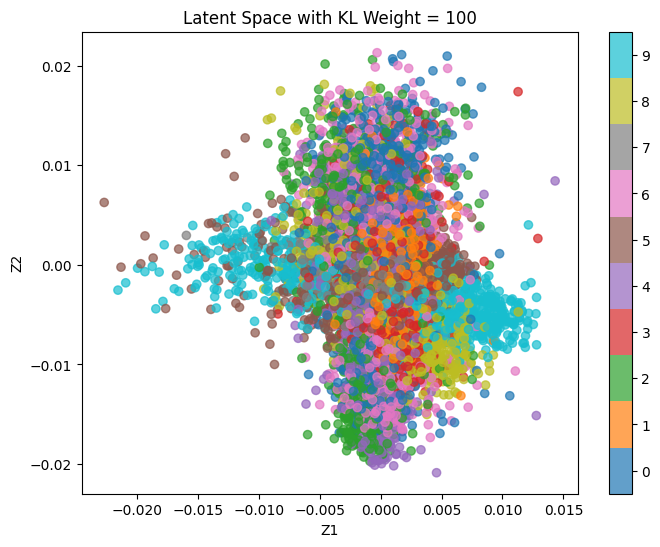

In [94]:
# Hyperparameters
latent_dims = 2
batch_size = 128
num_epochs = 10
learning_rate = 1e-3
kl_weights = [1, 10, 100]  # Different weights for the KL divergence term

# Training and plotting function
def train_and_plot(kl_weight):
    cvae = ConditionalVAE(latent_dims).to(device)
    optimizer = optim.Adam(cvae.parameters(), lr=learning_rate)
    
    cvae.train()
    train_losses = []
    BCE = []
    KLD = []
    val_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        bce_loss = 0.0
        kld_loss = 0.0
        for batch_idx, (data, label) in enumerate(train_loader):
            data = data.to(device)
            label = label.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = cvae(data, label)
            loss, bce, kld = loss_function(x_recon, data, mu, logvar, kl_weight)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            bce_loss += bce.item()
            kld_loss += kld.item()

              
        average_loss = epoch_loss / len(train_loader.dataset)
        average_bce = bce_loss / len(train_loader.dataset)
        average_kld = kld_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}: Average Loss: {average_loss:.4f}, BCE: {average_bce:.4f}, KLD: {average_kld:.4f}')
    
        train_losses.append(average_loss)
        BCE.append(average_bce)
        KLD.append(average_kld)

        # --- Validation ---
        cvae.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data, label) in enumerate(test_loader):
                data = data.to(device)
                label = label.to(device)
                recon_batch, mu, logvar = cvae(data, label)
                val_loss, _, _ = loss_function(recon_batch, data, mu, logvar)
                val_running_loss += val_loss.item()
        
        epoch_val_loss = val_running_loss / len(test_loader.dataset)
        val_losses.append(epoch_val_loss)


    # Plot latent space
    plot_latent_space(cvae, kl_weight)

# Function to plot latent space
def plot_latent_space(model, kl_weight):
    model.eval()
    with torch.no_grad():
        test_loader = DataLoader(dataset=test_dataset, batch_size=10000, shuffle=False)
        data, labels = next(iter(test_loader))
        data = data.to(device)
        label = labels.to(device)
        mu, logvar = model.encode(data, label)
        z = mu  # For visualization, we use the mean
        z = z.cpu().numpy()
        labels = labels.numpy()
        
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap='tab10', alpha=0.7)
        plt.colorbar(scatter, ticks=range(10))
        plt.clim(-0.5, 9.5)
        plt.title(f'Latent Space with KL Weight = {kl_weight}')
        plt.xlabel('Z1')
        plt.ylabel('Z2')
        plt.show()

# Run training and plotting for different KL weights
for kl_weight in kl_weights:
    print(f'\nTraining VAE with KL Weight = {kl_weight}')
    train_and_plot(kl_weight)



